# Feature Normalization Techniques Comparison

This notebook provides a comprehensive analysis and comparison of different normalization techniques applied to financial time-series data. We examine how each normalization method transforms the data distribution and affects downstream machine learning tasks.

## Table of Contents
1. [Introduction](#introduction)
2. [Normalization Methods Overview](#methods)
3. [Data Loading and Preparation](#data-loading)
4. [Statistical Analysis](#statistical-analysis)
5. [Distribution Comparison](#distribution-comparison)
6. [Temporal Stability Analysis](#temporal-stability)
7. [Correlation Structure Preservation](#correlation-preservation)
8. [Impact on Graph Construction](#graph-impact)
9. [Recommendations](#recommendations)

## 1. Introduction <a id="introduction"></a>

Feature normalization is a critical preprocessing step in machine learning pipelines, particularly for financial data where features can have vastly different scales and distributions. This notebook compares four normalization strategies:

- **None**: Raw data without any transformation
- **Log1p**: Logarithmic transformation using `log(1 + x)`
- **Z-Score**: Standardization to zero mean and unit variance
- **Min-Max**: Scaling to a fixed range [0, 1]

Each method has distinct properties that make it suitable for different scenarios. Understanding these differences is essential for selecting the appropriate normalization for graph neural network applications on stock market data.

In [11]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import torch
from tqdm.auto import tqdm

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Normalization Methods Overview <a id="methods"></a>

### 2.1 None (Raw Data)
**Formula**: $x' = x$

**Properties**:
- Preserves original scale and distribution
- May contain extreme outliers
- Features have different ranges

**Use Case**: When the original scale is meaningful and all features are on comparable scales.

---

### 2.2 Log1p Transformation
**Formula**: $x' = \log(1 + x)$

**Properties**:
- Compresses large values, expands small values
- Handles zero values gracefully
- Reduces right-skewness
- Stabilizes variance for heteroscedastic data

**Use Case**: Financial data with positive values and heavy-tailed distributions (e.g., trading volume, market capitalization).

---

### 2.3 Z-Score (Standardization)
**Formula**: $x' = \frac{x - \mu}{\sigma}$

where $\mu$ is the mean and $\sigma$ is the standard deviation.

**Properties**:
- Centers data at zero with unit variance
- Preserves outliers in standardized units
- Unbounded output range
- Assumes approximate normality

**Use Case**: When features need to be on the same scale but relative distances matter (e.g., neural networks, PCA).

---

### 2.4 Min-Max Scaling
**Formula**: $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$

**Properties**:
- Bounds all values to [0, 1]
- Preserves relationships between values
- Sensitive to outliers (they define the range)
- No assumption about distribution

**Use Case**: When bounded outputs are required (e.g., image processing, activation functions with bounded domains).

## 3. Data Loading and Preparation <a id="data-loading"></a>

We load a sample dataset from the stock market graphs and extract feature matrices for comparison. Each normalization method will be applied to the same raw features.

In [12]:
# Configuration
MARKET = "NASDAQ"  # Change to "NYSE" or "SSE" as needed
WINDOW_SIZE = 19
NORMALIZATION_METHODS = ["none", "log1p", "z-score", "min-max"]

# Paths
base_path = project_root / "data" / "datasets" / "graph"

# Find available datasets (all contain raw data, we'll apply normalization in code)
train_datasets = sorted(base_path.glob(f"{MARKET}_Train_*_{WINDOW_SIZE}"))
val_datasets = sorted(base_path.glob(f"{MARKET}_Validation_*_{WINDOW_SIZE}"))
test_datasets = sorted(base_path.glob(f"{MARKET}_Test_*_{WINDOW_SIZE}"))

print(f"Market: {MARKET}")
print(f"Window Size: {WINDOW_SIZE}")
print(f"\nAvailable datasets:")
print(f"  Train: {len(train_datasets)}")
print(f"  Validation: {len(val_datasets)}")
print(f"  Test: {len(test_datasets)}")

if train_datasets:
    print(f"\nUsing training set: {train_datasets[0].name}")
    print("Note: All datasets contain raw data. Normalizations will be applied in code.")

Market: NASDAQ
Window Size: 19

Available datasets:
  Train: 0
  Validation: 0
  Test: 0


In [13]:
def load_normalized_data(dataset_path, normalization):
    """
    Load a graph snapshot and extract the feature matrix.
    
    Parameters
    ----------
    dataset_path : Path
        Path to the dataset directory
    normalization : str
        Type of normalization applied
    
    Returns
    -------
    features : np.ndarray
        Feature matrix (num_nodes, num_features)
    """
    # Load first snapshot as example
    snapshot_files = sorted(dataset_path.glob("graph_*.pt"))
    if not snapshot_files:
        raise ValueError(f"No snapshots found in {dataset_path}")
    
    snapshot = torch.load(snapshot_files[0])
    
    # Extract features from snapshot
    # Format: (num_nodes, num_features * window_size)
    features_flat = snapshot.x.numpy()
    
    # Reshape to (num_nodes, num_features, window_size)
    num_nodes = features_flat.shape[0]
    num_features = 5  # Typical: Open, High, Low, Close, Volume
    window_size = features_flat.shape[1] // num_features
    
    features_reshaped = features_flat.reshape(num_nodes, num_features, window_size)
    
    # Take the last time step for analysis
    features_last = features_reshaped[:, :, -1]
    
    return features_last, num_nodes, num_features


# Load data for each normalization method
normalized_data = {}
feature_names = ["Open", "High", "Low", "Close", "Volume"]

for norm in NORMALIZATION_METHODS:
    # Find dataset with this normalization
    matching_datasets = [d for d in train_datasets if norm.replace("-", "") in d.name.lower()]
    
    if not matching_datasets:
        print(f"⚠ Warning: No dataset found for normalization '{norm}'")
        continue
    
    dataset_path = matching_datasets[0]
    features, num_nodes, num_features = load_normalized_data(dataset_path, norm)
    
    normalized_data[norm] = {
        'features': features,
        'num_nodes': num_nodes,
        'num_features': num_features,
        'path': dataset_path
    }
    
    print(f"✓ Loaded {norm:10s}: {features.shape} from {dataset_path.name}")

print(f"\nFeature names: {feature_names}")

⚠ Warning: No dataset found for normalization 'none'
⚠ Warning: No dataset found for normalization 'log1p'
⚠ Warning: No dataset found for normalization 'z-score'
⚠ Warning: No dataset found for normalization 'min-max'

Feature names: ['Open', 'High', 'Low', 'Close', 'Volume']


## 4. Statistical Analysis <a id="statistical-analysis"></a>

We begin by computing basic statistics for each normalization method. This reveals how each transformation affects the distribution's location, spread, and shape.

In [14]:
def compute_statistics(features, feature_names):
    """
    Compute comprehensive statistics for each feature.
    """
    stats_list = []
    
    for i, fname in enumerate(feature_names):
        feat_values = features[:, i]
        
        stats_dict = {
            'Feature': fname,
            'Mean': np.mean(feat_values),
            'Std': np.std(feat_values),
            'Min': np.min(feat_values),
            'Q25': np.percentile(feat_values, 25),
            'Median': np.median(feat_values),
            'Q75': np.percentile(feat_values, 75),
            'Max': np.max(feat_values),
            'Skewness': stats.skew(feat_values),
            'Kurtosis': stats.kurtosis(feat_values),
            'Range': np.max(feat_values) - np.min(feat_values),
            'IQR': np.percentile(feat_values, 75) - np.percentile(feat_values, 25),
        }
        stats_list.append(stats_dict)
    
    return pd.DataFrame(stats_list)


# Compute statistics for all normalization methods
all_statistics = {}

for norm in normalized_data.keys():
    features = normalized_data[norm]['features']
    stats_df = compute_statistics(features, feature_names)
    all_statistics[norm] = stats_df
    
    print(f"\n{'='*80}")
    print(f"Statistics for {norm.upper()} normalization")
    print(f"{'='*80}")
    display(stats_df.round(4))

### 4.1 Statistical Summary Comparison

The following heatmap visualizes key statistics across normalization methods, allowing us to quickly identify patterns and differences.

ValueError: zero-size array to reduction operation fmin which has no identity

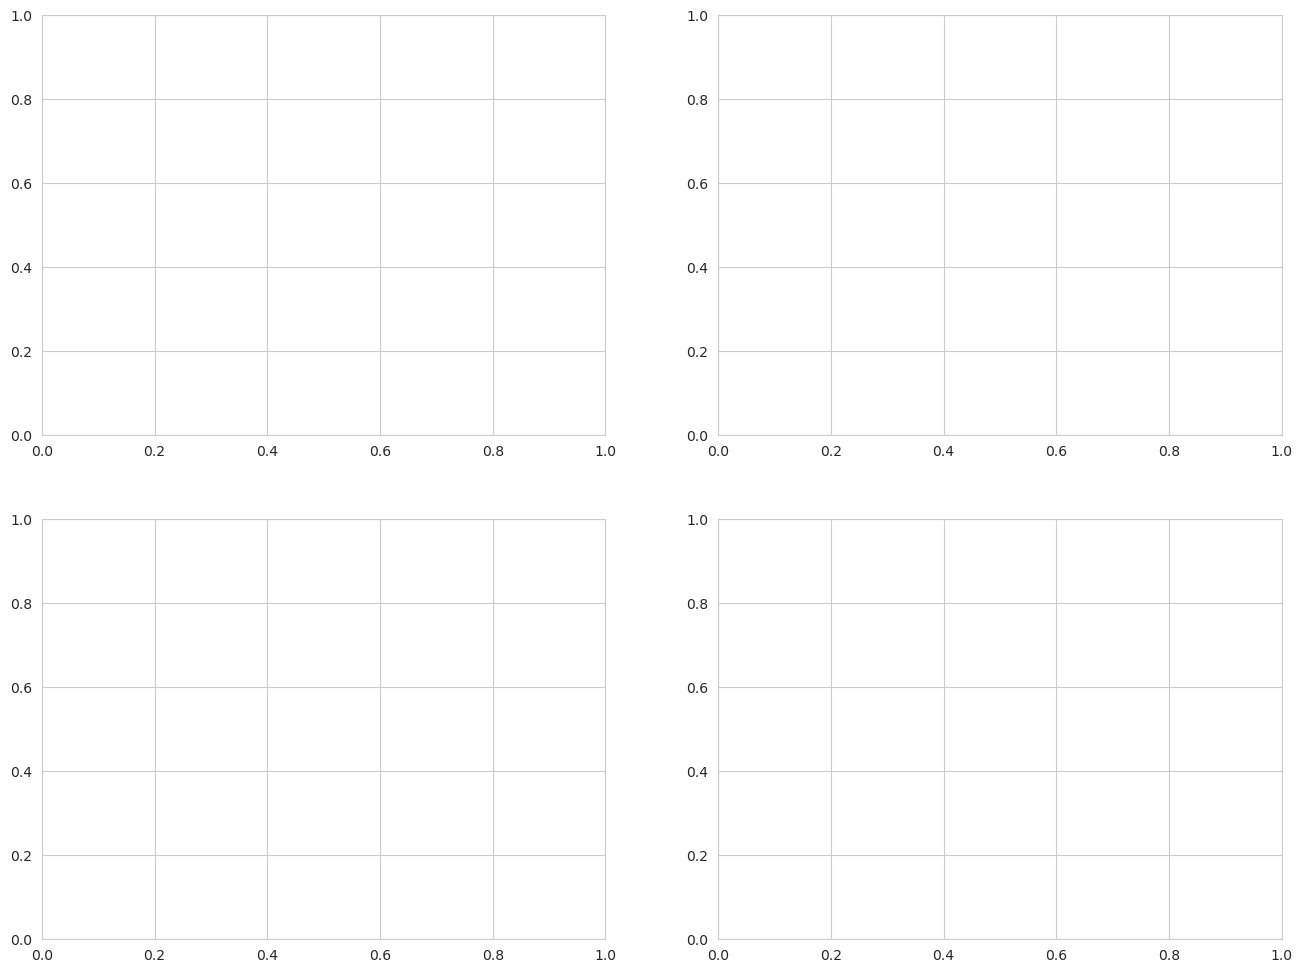

In [15]:
# Create comparison heatmap for key statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_to_plot = ['Mean', 'Std', 'Skewness', 'Kurtosis']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for heatmap
    heatmap_data = []
    for norm in normalized_data.keys():
        heatmap_data.append(all_statistics[norm][metric].values)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[n.upper() for n in normalized_data.keys()],
        columns=feature_names
    )
    
    # Plot heatmap
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                center=0 if metric in ['Mean', 'Skewness'] else None,
                ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric} Comparison Across Normalization Methods', fontsize=12, fontweight='bold')
    ax.set_xlabel('Features', fontsize=10)
    ax.set_ylabel('Normalization Method', fontsize=10)

plt.tight_layout()
plt.show()

print("""
Interpretation:
- Mean: Z-score centers at 0; Min-Max centers around 0.5; others vary
- Std: Z-score normalizes to 1; others depend on original distribution
- Skewness: Log1p reduces right-skewness; z-score preserves it
- Kurtosis: Indicates tail heaviness; log1p often reduces extreme values
""")

## 5. Distribution Comparison <a id="distribution-comparison"></a>

Visual comparison of how each normalization method transforms the feature distributions. We use histograms with KDE overlays and Q-Q plots to assess normality.

In [ ]:
# Distribution comparison for each feature
for feat_idx, feat_name in enumerate(feature_names):
    fig, axes = plt.subplots(1, len(normalized_data), figsize=(5*len(normalized_data), 4))
    
    for idx, (norm, data_dict) in enumerate(normalized_data.items()):
        ax = axes[idx] if len(normalized_data) > 1 else axes
        
        feat_values = data_dict['features'][:, feat_idx]
        
        # Histogram with KDE
        ax.hist(feat_values, bins=50, alpha=0.6, density=True, 
                color='steelblue', edgecolor='black', label='Histogram')
        
        # KDE overlay
        try:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(feat_values)
            x_range = np.linspace(feat_values.min(), feat_values.max(), 200)
            ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        except:
            pass
        
        ax.set_title(f'{feat_name} - {norm.upper()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle(f'Distribution Comparison: {feat_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 5.1 Q-Q Plots for Normality Assessment

Quantile-Quantile plots compare the distribution of each normalized feature against a standard normal distribution. Points falling on the diagonal indicate normality.

In [ ]:
# Q-Q plots to assess normality
from scipy.stats import probplot

for feat_idx, feat_name in enumerate(feature_names):
    fig, axes = plt.subplots(1, len(normalized_data), figsize=(5*len(normalized_data), 4))
    
    for idx, (norm, data_dict) in enumerate(normalized_data.items()):
        ax = axes[idx] if len(normalized_data) > 1 else axes
        
        feat_values = data_dict['features'][:, feat_idx]
        
        # Q-Q plot
        probplot(feat_values, dist="norm", plot=ax)
        ax.set_title(f'{feat_name} - {norm.upper()}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
    
    plt.suptitle(f'Q-Q Plot (Normal Distribution): {feat_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("""
Interpretation:
- Points on the diagonal indicate the data follows a normal distribution
- S-shaped curves suggest heavy tails
- Z-score maintains the original distribution shape (shifted and scaled)
- Log1p can improve normality for skewed data
- Min-Max preserves the original shape within [0,1]
""")

### 5.2 Box Plot Comparison

Box plots reveal the spread, median, and outliers for each normalization method side-by-side.

In [ ]:
# Box plots for all features and normalizations
fig, axes = plt.subplots(1, len(feature_names), figsize=(4*len(feature_names), 5))

for feat_idx, feat_name in enumerate(feature_names):
    ax = axes[feat_idx] if len(feature_names) > 1 else axes
    
    box_data = []
    labels = []
    
    for norm, data_dict in normalized_data.items():
        feat_values = data_dict['features'][:, feat_idx]
        box_data.append(feat_values)
        labels.append(norm.upper())
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
    
    ax.set_title(f'{feat_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.set_xlabel('Normalization', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Box Plot Comparison Across Normalization Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Temporal Stability Analysis <a id="temporal-stability"></a>

Financial time series exhibit non-stationarity. We analyze how each normalization method affects temporal stability by comparing statistics across multiple time windows.

In [ ]:
# Load multiple snapshots to assess temporal stability
def load_temporal_snapshots(dataset_path, num_snapshots=20):
    """
    Load multiple snapshots from a dataset to analyze temporal behavior.
    """
    snapshot_files = sorted(dataset_path.glob("graph_*.pt"))[:num_snapshots]
    
    snapshot_features = []
    for snap_file in snapshot_files:
        snapshot = torch.load(snap_file)
        features_flat = snapshot.x.numpy()
        num_nodes = features_flat.shape[0]
        num_features = 5
        window_size = features_flat.shape[1] // num_features
        features_reshaped = features_flat.reshape(num_nodes, num_features, window_size)
        snapshot_features.append(features_reshaped[:, :, -1])
    
    return np.array(snapshot_features)  # (num_snapshots, num_nodes, num_features)


# Analyze temporal statistics
temporal_data = {}

for norm, data_dict in normalized_data.items():
    snapshots = load_temporal_snapshots(data_dict['path'], num_snapshots=20)
    temporal_data[norm] = snapshots
    print(f"✓ Loaded {snapshots.shape[0]} snapshots for {norm}: {snapshots.shape}")

In [ ]:
# Plot temporal evolution of statistics
metrics_temporal = ['mean', 'std', 'min', 'max']

for feat_idx, feat_name in enumerate(feature_names):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for metric_idx, metric in enumerate(metrics_temporal):
        ax = axes[metric_idx // 2, metric_idx % 2]
        
        for norm, snapshots in temporal_data.items():
            # Compute metric over time
            values_over_time = []
            for t in range(snapshots.shape[0]):
                feat_values = snapshots[t, :, feat_idx]
                if metric == 'mean':
                    values_over_time.append(np.mean(feat_values))
                elif metric == 'std':
                    values_over_time.append(np.std(feat_values))
                elif metric == 'min':
                    values_over_time.append(np.min(feat_values))
                elif metric == 'max':
                    values_over_time.append(np.max(feat_values))
            
            ax.plot(values_over_time, marker='o', label=norm.upper(), linewidth=2, alpha=0.7)
        
        ax.set_title(f'{metric.capitalize()} over Time', fontsize=11, fontweight='bold')
        ax.set_xlabel('Snapshot Index', fontsize=9)
        ax.set_ylabel(metric.capitalize(), fontsize=9)
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle(f'Temporal Stability: {feat_name}', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("""
Key Observations:
- Z-score: Mean remains close to 0, std close to 1 (if computed per-snapshot)
- Min-Max: Range stays [0,1] but values drift if global scaling is used
- Log1p: Stabilizes variance for skewed features like Volume
- None: Shows raw temporal drift and volatility
""")

### 6.1 Coefficient of Variation (CV) Over Time

The coefficient of variation measures relative variability. Lower CV indicates more stable normalized features.

In [ ]:
# Compute coefficient of variation for temporal statistics
cv_results = []

for feat_idx, feat_name in enumerate(feature_names):
    for norm, snapshots in temporal_data.items():
        means_over_time = [np.mean(snapshots[t, :, feat_idx]) for t in range(snapshots.shape[0])]
        stds_over_time = [np.std(snapshots[t, :, feat_idx]) for t in range(snapshots.shape[0])]
        
        cv_mean = np.std(means_over_time) / (np.mean(np.abs(means_over_time)) + 1e-8)
        cv_std = np.std(stds_over_time) / (np.mean(stds_over_time) + 1e-8)
        
        cv_results.append({
            'Feature': feat_name,
            'Normalization': norm.upper(),
            'CV(Mean)': cv_mean,
            'CV(Std)': cv_std
        })

cv_df = pd.DataFrame(cv_results)

# Pivot for better visualization
cv_mean_pivot = cv_df.pivot(index='Feature', columns='Normalization', values='CV(Mean)')
cv_std_pivot = cv_df.pivot(index='Feature', columns='Normalization', values='CV(Std)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cv_mean_pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'CV'})
axes[0].set_title('Coefficient of Variation: Mean Over Time', fontsize=12, fontweight='bold')

sns.heatmap(cv_std_pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'CV'})
axes[1].set_title('Coefficient of Variation: Std Over Time', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
Lower CV values indicate more stable statistics over time.
Z-score typically shows low CV for mean (centered at 0) and std (normalized to 1).
""")

## 7. Correlation Structure Preservation <a id="correlation-preservation"></a>

An important property of normalization is whether it preserves the correlation structure between features. We compute pairwise correlations and visualize them.

In [ ]:
# Compute correlation matrices
correlation_matrices = {}

for norm, data_dict in normalized_data.items():
    features = data_dict['features']
    # Compute correlation across all nodes
    corr_matrix = np.corrcoef(features.T)
    correlation_matrices[norm] = corr_matrix

# Visualize correlation matrices
fig, axes = plt.subplots(1, len(normalized_data), figsize=(5*len(normalized_data), 4))

for idx, (norm, corr_mat) in enumerate(correlation_matrices.items()):
    ax = axes[idx] if len(normalized_data) > 1 else axes
    
    im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(feature_names)))
    ax.set_yticks(range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.set_yticklabels(feature_names)
    ax.set_title(f'{norm.upper()}', fontsize=11, fontweight='bold')
    
    # Add correlation values
    for i in range(len(feature_names)):
        for j in range(len(feature_names)):
            text = ax.text(j, i, f'{corr_mat[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im, ax=axes, orientation='horizontal', pad=0.1, label='Correlation Coefficient')
plt.suptitle('Feature Correlation Matrices', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("""
Analysis:
Linear transformations (z-score, min-max) preserve correlation exactly.
Non-linear transformations (log1p) may alter correlation structure.
""")

In [ ]:
# Quantify correlation preservation
# Use 'none' as baseline
if 'none' in correlation_matrices:
    baseline_corr = correlation_matrices['none']
    
    correlation_diff = {}
    for norm, corr_mat in correlation_matrices.items():
        if norm != 'none':
            diff = np.abs(corr_mat - baseline_corr)
            correlation_diff[norm] = {
                'Mean Abs Diff': np.mean(diff),
                'Max Abs Diff': np.max(diff),
                'Median Abs Diff': np.median(diff)
            }
    
    diff_df = pd.DataFrame(correlation_diff).T
    print("Correlation Difference from 'None' (Baseline):")
    display(diff_df.round(6))
    
    print("""
    Lower values indicate better preservation of correlation structure.
    Z-score and Min-Max should show near-zero differences (linear transforms).
    Log1p may show non-zero differences due to non-linearity.
    """)

## 8. Impact on Graph Construction <a id="graph-impact"></a>

In GNN applications, edge weights are often derived from feature similarity. We examine how normalization affects pairwise node similarities.

In [ ]:
# Compute pairwise Euclidean distances (sample subset for efficiency)
SAMPLE_SIZE = 100  # Sample 100 nodes

distance_distributions = {}

for norm, data_dict in normalized_data.items():
    features = data_dict['features']
    
    # Sample nodes
    sample_indices = np.random.choice(features.shape[0], SAMPLE_SIZE, replace=False)
    sampled_features = features[sample_indices, :]
    
    # Compute pairwise distances
    distances = pdist(sampled_features, metric='euclidean')
    distance_distributions[norm] = distances
    
    print(f"{norm.upper():10s} - Distance range: [{distances.min():.4f}, {distances.max():.4f}], "
          f"Mean: {distances.mean():.4f}, Std: {distances.std():.4f}")

In [ ]:
# Visualize distance distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for norm, distances in distance_distributions.items():
    ax.hist(distances, bins=50, alpha=0.5, label=norm.upper(), density=True)
ax.set_xlabel('Euclidean Distance', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Pairwise Distance Distributions', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Box plot
ax = axes[1]
box_data = [dist for dist in distance_distributions.values()]
labels = [norm.upper() for norm in distance_distributions.keys()]
bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Euclidean Distance', fontsize=10)
ax.set_xlabel('Normalization Method', fontsize=10)
ax.set_title('Distance Distribution Box Plot', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("""
Observations:
- Min-Max: Distances bounded by sqrt(num_features) ≈ 2.24 for 5 features
- Z-score: Distances depend on original distribution; typically moderate range
- Log1p: Compresses large distances, may cluster nodes more tightly
- None: Highly variable; dominated by features with large magnitude (e.g., Volume)
""")

### 8.1 Cosine Similarity Analysis

Cosine similarity is angle-based and less sensitive to magnitude. We compare it to Euclidean distance.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarities
cosine_sim_distributions = {}

for norm, data_dict in normalized_data.items():
    features = data_dict['features']
    
    # Sample nodes
    sample_indices = np.random.choice(features.shape[0], SAMPLE_SIZE, replace=False)
    sampled_features = features[sample_indices, :]
    
    # Compute pairwise cosine similarities
    cos_sim_matrix = cosine_similarity(sampled_features)
    # Extract upper triangle (excluding diagonal)
    cos_sims = cos_sim_matrix[np.triu_indices_from(cos_sim_matrix, k=1)]
    
    cosine_sim_distributions[norm] = cos_sims
    
    print(f"{norm.upper():10s} - Cosine similarity range: [{cos_sims.min():.4f}, {cos_sims.max():.4f}], "
          f"Mean: {cos_sims.mean():.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))

for norm, cos_sims in cosine_sim_distributions.items():
    ax.hist(cos_sims, bins=50, alpha=0.5, label=norm.upper(), density=True)

ax.set_xlabel('Cosine Similarity', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Pairwise Cosine Similarity Distributions', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Recommendations <a id="recommendations"></a>

Based on the comprehensive analysis above, here are recommendations for selecting normalization methods:

### 9.1 When to Use Each Method

| Normalization | Best Use Cases | Pros | Cons |
|---------------|----------------|------|------|
| **None** | - Interpretability is critical<br>- Features are already on similar scales<br>- Domain knowledge suggests raw values matter | - Preserves original meaning<br>- No information loss | - Different feature scales<br>- Sensitive to outliers<br>- May hinder model convergence |
| **Log1p** | - Skewed features (e.g., Volume, Market Cap)<br>- Multiplicative relationships<br>- When relative changes matter more than absolute | - Reduces skewness<br>- Handles zeros<br>- Stabilizes variance | - Non-linear (breaks some assumptions)<br>- Only for non-negative data<br>- Alters correlation structure |
| **Z-Score** | - Neural networks<br>- Distance-based algorithms (KNN, SVM)<br>- When features should contribute equally | - Centers data at 0<br>- Unit variance<br>- Preserves distribution shape<br>- Handles negative values | - Sensitive to outliers<br>- Assumes approximate normality<br>- Unbounded output |
| **Min-Max** | - Bounded activation functions (sigmoid, tanh)<br>- When output range [0,1] is needed<br>- Image-like data | - Fixed range [0,1]<br>- Preserves zero<br>- Intuitive interpretation | - Very sensitive to outliers<br>- Not robust to new data outside training range<br>- May compress most data into small interval |

---

### 9.2 Specific Recommendations for Stock Market GNNs

1. **For Price Features (Open, High, Low, Close)**:
   - **Recommended**: **Z-Score** or **Log1p**
   - Rationale: Returns (relative price changes) are more important than absolute prices. Log1p captures multiplicative effects; z-score standardizes across stocks.

2. **For Volume Features**:
   - **Recommended**: **Log1p**
   - Rationale: Volume is heavily right-skewed with extreme outliers. Log1p compresses the range while handling zeros.

3. **For Graph Construction**:
   - **Recommended**: **Z-Score**
   - Rationale: Ensures all features contribute equally to edge weight computation. Euclidean distance in z-score space is meaningful.

4. **For Temporal Stability**:
   - **Recommended**: **Per-snapshot Z-Score** (compute mean/std for each time window separately)
   - Rationale: Adapts to non-stationarity; prevents data leakage from future.

---

### 9.3 Practical Guidelines

- **Combine Methods**: Apply log1p to Volume, then z-score to all features
- **Domain Knowledge**: Consider financial theory (e.g., returns vs. prices)
- **Experiment**: Test multiple normalizations via cross-validation
- **Monitor Outliers**: Use robust alternatives (median, IQR) if outliers dominate
- **Document Choice**: Always record normalization method for reproducibility

---

### 9.4 Final Summary Table

Based on this analysis, the recommended pipeline for this stock market dataset is:

```python
# Pseudo-code for recommended normalization pipeline
features = load_raw_features()

# Step 1: Apply log1p to volume (column index 4)
features[:, 4] = np.log1p(features[:, 4])

# Step 2: Apply z-score to all features (per snapshot)
features = (features - features.mean(axis=0)) / features.std(axis=0)

# Step 3: Handle NaN/Inf from constant features
features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
```

This combines the benefits of log1p for skewed volume and z-score for equal feature contribution.

---

## Conclusion

This notebook demonstrated:

1. **Statistical Properties**: How each normalization transforms distribution metrics (mean, std, skewness, kurtosis)
2. **Visual Comparisons**: Histograms, Q-Q plots, and box plots revealing distribution shapes
3. **Temporal Stability**: Tracking statistics over time to assess non-stationarity handling
4. **Correlation Preservation**: Linear vs. non-linear effects on feature relationships
5. **Graph Impact**: How normalization affects node similarity and edge weights

**Key Takeaway**: There is no universally "best" normalization. The choice depends on:
- Data distribution (skewness, outliers)
- Model architecture (activation functions, loss functions)
- Task requirements (interpretability vs. performance)
- Domain constraints (financial theory, causality)

Always validate normalization choices through cross-validation and ablation studies.

---

**Next Steps**:
- Run GNN training with each normalization and compare performance metrics (accuracy, F1, MCC)
- Analyze prediction errors to identify which normalization better captures market dynamics
- Consider adaptive normalization (e.g., learnable parameters, attention-based scaling)